# Four-frequency FBTDCA training — 2-second epochs

Train and validate a subject-specific 8/9/13/14 Hz model using exactly 2.0 seconds (500 samples at 250 Hz) from each recorded trial. This is a separate experiment from the original 3.5-second model and does not overwrite it.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ssvep_bci.training import (
    load_fbtdca_dataset,
    save_fbtdca_model, train_fbtdca,
)

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "ssvep-bci" / "pyproject.toml").is_file():
            return candidate
        if (candidate / "src" / "ssvep_bci").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the BCI repository root")

REPO_ROOT = find_repo_root()
PARTICIPANT_ID = "mike_a"
WINDOW_LENGTH_SECONDS = 2.0
SESSION_PATHS = [
    REPO_ROOT / "ssvep-bci/sessions/20260801T192258Z_mike_a_fbtdca-run-1_a299483b",
    REPO_ROOT / "ssvep-bci/sessions/20260801T193028Z_mike_a_fbtdca-run-2_f940ff62",
]
MODEL_PATH = REPO_ROOT / "ssvep-bci/models/mike_a/four_frequency_fbtdca_2s.joblib"

## Extract timestamp-aligned 2-second epochs

In [7]:
missing_paths = [path for path in SESSION_PATHS if not path.is_dir()]
if missing_paths:
    raise FileNotFoundError(f"Missing configured session folders: {missing_paths}")
dataset = load_fbtdca_dataset(
    SESSION_PATHS, PARTICIPANT_ID,
    window_length_seconds=WINDOW_LENGTH_SECONDS
)
print("Sessions:", len(dataset.session_paths))
print("EEG shape (trials, channels, samples):", dataset.eeg.shape)
print("Epoch duration:", dataset.window_length_seconds, "seconds")
print("Frequencies:", dataset.candidate_frequencies_hz)
print("Excluded incomplete trials:", len(dataset.excluded_trials))
print("Trials per class:", np.bincount(dataset.labels, minlength=4))

Sessions: 2
EEG shape (trials, channels, samples): (96, 8, 500)
Epoch duration: 2.0 seconds
Frequencies: (8.0, 9.0, 13.0, 14.0)
Excluded incomplete trials: 0
Trials per class: [24 24 24 24]


## Leave-one-session-out validation and final fit

In [8]:
estimator, validation = train_fbtdca(dataset)
for fold in validation["folds"]:
    print(f"{fold['held_out_session_id']}: balanced accuracy {fold['balanced_accuracy']:.3f}")
print(f"Overall accuracy: {validation['accuracy']:.3f}")
print(f"Overall balanced accuracy: {validation['balanced_accuracy']:.3f}")

a299483b-4715-4168-99be-cbdf9d6f5dc0: balanced accuracy 0.812
f940ff62-e339-49c0-9c9c-29293f19e9b8: balanced accuracy 0.979
Overall accuracy: 0.896
Overall balanced accuracy: 0.896


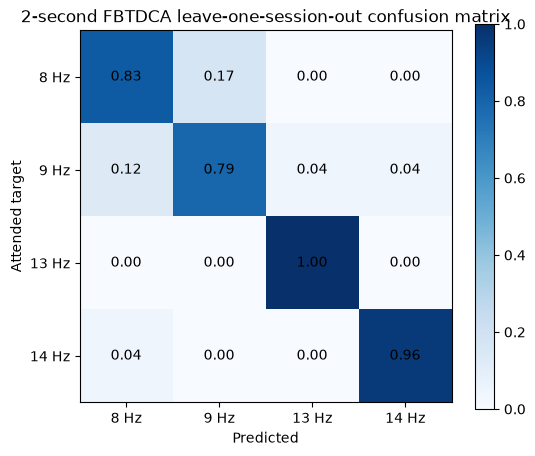

In [9]:
matrix = np.asarray(validation["normalized_confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
labels = [f"{value:g} Hz" for value in dataset.candidate_frequencies_hz]
ax.set(xticks=range(4), yticks=range(4), xticklabels=labels, yticklabels=labels,
       xlabel="Predicted", ylabel="Attended target",
       title="2-second FBTDCA leave-one-session-out confusion matrix")
for row in range(4):
    for column in range(4):
        ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.show()

## Save the separate 2-second model and reproducibility metadata

In [10]:
saved_model, saved_summary = save_fbtdca_model(
    dataset, estimator, validation, MODEL_PATH
)
print("Saved model:", saved_model)
print("Saved summary:", saved_summary)

Saved model: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\four_frequency_fbtdca_2s.joblib
Saved summary: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\models\mike_a\four_frequency_fbtdca_2s_summary.json
